In [1]:
import os, random
import numpy as np
from pathlib import Path
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import torchvision.models as models

import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)
torch.backends.cudnn.benchmark = True

device = cpu


In [3]:
def load_att(root):
    root = Path(root)
    by_id = {}
    for person_dir in sorted(root.glob("s*")):
        pid = int(person_dir.name[1:])
        imgs = []
        for p in sorted(person_dir.glob("*.pgm")):
            img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            imgs.append(img)
        if imgs:
            by_id[pid] = imgs
    return by_id

faces_by_id = load_att('/home/bargomix/Documents/secondcourse/PAC/semister4/lab2/datasets/kasikrit/att-database-of-faces/versions/2')  # или путь к папке датасета
print("people:", len(faces_by_id), "images per person (example):", len(next(iter(faces_by_id.values()))))

people: 40 images per person (example): 10


In [4]:
def split_by_identity(faces_by_id, val_ids_count=10, seed=42):
    ids = sorted(list(faces_by_id.keys()))
    rng = random.Random(seed)
    rng.shuffle(ids)
    val_ids = set(ids[:val_ids_count])
    train_ids = set(ids[val_ids_count:])
    train_data = {pid: faces_by_id[pid] for pid in train_ids}
    val_data   = {pid: faces_by_id[pid] for pid in val_ids}
    return train_data, val_data

train_faces, val_faces = split_by_identity(faces_by_id, val_ids_count=10)
print("train people:", len(train_faces), "val people:", len(val_faces))

train people: 30 val people: 10


In [5]:
def make_pairs(by_id, n_pairs=20000, seed=42):
    rng = random.Random(seed)
    ids = list(by_id.keys())
    pairs = []
    half = n_pairs // 2

    # positive (same person)
    for _ in range(half):
        pid = rng.choice(ids)
        if len(by_id[pid]) < 2:
            continue
        a, b = rng.sample(by_id[pid], 2)
        pairs.append((a, b, 1))

    # negative (different persons)
    for _ in range(n_pairs - len(pairs)):
        pid1, pid2 = rng.sample(ids, 2)
        a = rng.choice(by_id[pid1])
        b = rng.choice(by_id[pid2])
        pairs.append((a, b, 0))

    rng.shuffle(pairs)
    return pairs

train_pairs = make_pairs(train_faces, n_pairs=20000, seed=1)
val_pairs   = make_pairs(val_faces,   n_pairs=4000,  seed=2)

print("train pairs:", len(train_pairs), "val pairs:", len(val_pairs))
print("val pos/neg:", sum(l for *_, l in val_pairs), len(val_pairs) - sum(l for *_, l in val_pairs))

train pairs: 20000 val pairs: 4000
val pos/neg: 2000 2000


In [6]:
from PIL import Image

class ToPIL:
    def __call__(self, img_np):
        return Image.fromarray(img_np)

transform = T.Compose([
    ToPIL(),
    T.Resize((112, 112)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

class FacePairsDataset(Dataset):
    def __init__(self, pairs, transform):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1, img2, label = self.pairs[idx]
        x1 = self.transform(img1)
        x2 = self.transform(img2)
        y  = torch.tensor(label, dtype=torch.float32)
        return x1, x2, y

train_loader = DataLoader(FacePairsDataset(train_pairs, transform), batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(FacePairsDataset(val_pairs,   transform), batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

In [7]:
class EmbeddingNet(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        m = models.resnet18(weights=None)
        m.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        m.fc = nn.Linear(m.fc.in_features, emb_dim)
        self.net = m

    def forward(self, x):
        z = self.net(x)
        return F.normalize(z, p=2, dim=1)

class SiameseNet(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        self.emb = EmbeddingNet(emb_dim)

    def forward(self, x1, x2):
        return self.emb(x1), self.emb(x2)

class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, z1, z2, y):
        d = F.pairwise_distance(z1, z2)      # [B]
        loss_pos = y * (d ** 2)
        loss_neg = (1 - y) * (torch.clamp(self.margin - d, min=0.0) ** 2)
        return (loss_pos + loss_neg).mean()
    
model = SiameseNet(emb_dim=128).to(device)
criterion = ContrastiveLoss(margin=1.0).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [8]:
def train_epoch(loader):
    model.train()
    total = 0.0
    for x1, x2, y in loader:
        x1, x2, y = x1.to(device), x2.to(device), y.to(device)
        optimizer.zero_grad()
        z1, z2 = model(x1, x2)
        loss = criterion(z1, z2, y)
        loss.backward()
        optimizer.step()
        total += loss.item() * x1.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def eval_distances(loader):
    model.eval()
    all_d, all_y = [], []
    for x1, x2, y in loader:
        x1, x2 = x1.to(device), x2.to(device)
        z1, z2 = model(x1, x2)
        d = F.pairwise_distance(z1, z2).cpu()
        all_d.append(d)
        all_y.append(y)
    return torch.cat(all_d).numpy(), torch.cat(all_y).numpy()

for epoch in range(10):
    tr_loss = train_epoch(train_loader)
    d, y = eval_distances(val_loader)
    # фиксируем порог с train (честнее), но быстро можно показать и вал-стат:
    thr = np.median(d)  # простой порог для мониторинга
    pred = (d < thr).astype(np.float32)
    acc = (pred == y).mean()
    print(f"epoch {epoch+1:02d}: loss={tr_loss:.4f}  val_acc~={acc:.3f}")

/home/bargomix/python/python/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

In [10]:
class SingleFacesDataset(Dataset):
    def __init__(self, by_id, transform):
        self.items = []
        for pid, imgs in by_id.items():
            for img in imgs:
                self.items.append((img, pid))
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img, pid = self.items[idx]
        return self.transform(img), pid

@torch.no_grad()
def collect_embeddings(by_id):
    ds = SingleFacesDataset(by_id, transform)
    dl = DataLoader(ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
    model.eval()
    Z, Y = [], []
    for x, pid in dl:
        x = x.to(device)
        z = model.emb(x).cpu().numpy()
        Z.append(z)
        Y.append(np.array(pid))
    return np.vstack(Z), np.concatenate(Y)

Z, Y = collect_embeddings(val_faces)  # можно train_faces или все faces_by_id
print(Z.shape, Y.shape)

(100, 128) (100,)


/tmp/ipykernel_12394/3052928147.py:26: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  Y.append(np.array(pid))


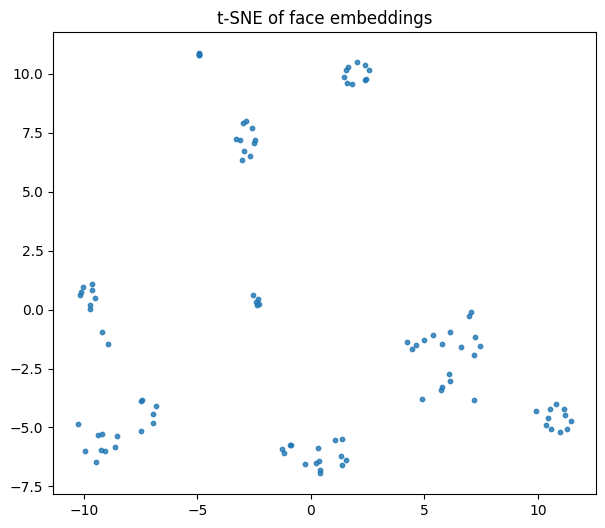

In [11]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=15, init="pca", learning_rate="auto", random_state=42)
Z2 = tsne.fit_transform(Z)

plt.figure(figsize=(7, 6))
plt.scatter(Z2[:,0], Z2[:,1], s=10, alpha=0.8)
plt.title("t-SNE of face embeddings")
plt.show()

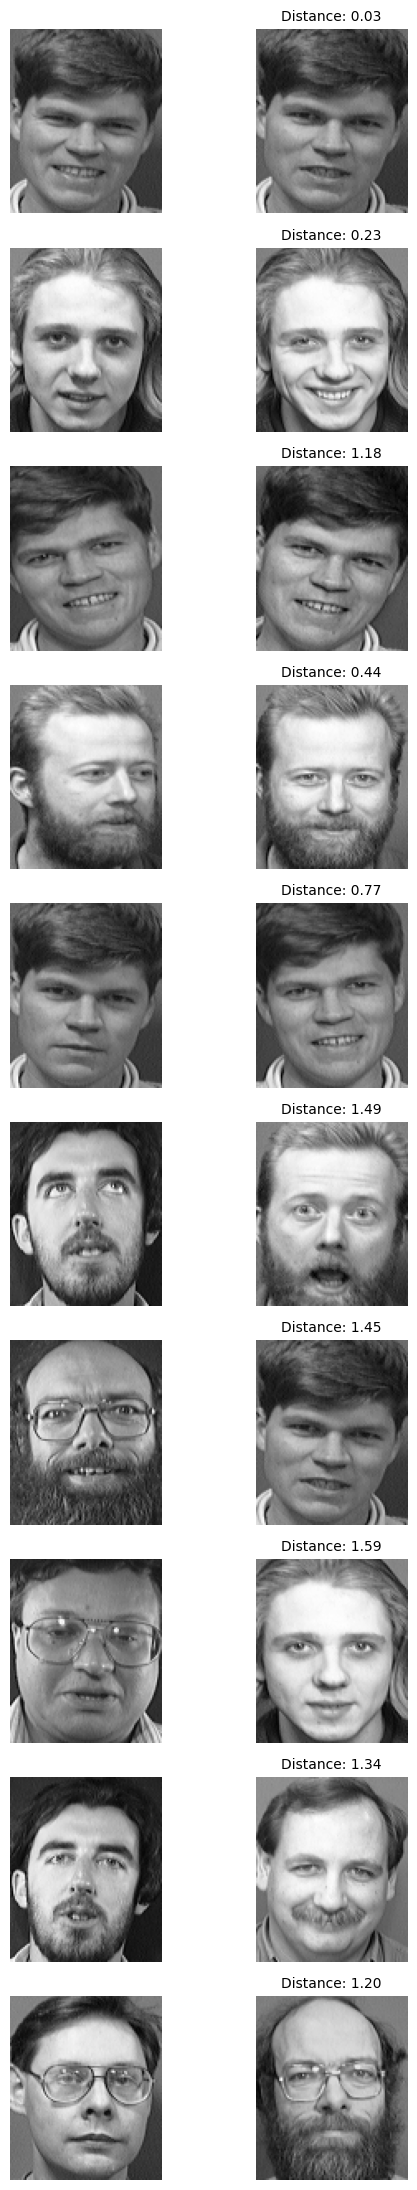

In [12]:
@torch.no_grad()
def distance_of_pair(img1, img2):
    x1 = transform(img1).unsqueeze(0).to(device)
    x2 = transform(img2).unsqueeze(0).to(device)
    z1, z2 = model(x1, x2)
    d = F.pairwise_distance(z1, z2).item()
    return d

def sample_inference_pairs(by_id, n_same=5, n_diff=5, seed=0):
    rng = random.Random(seed)
    ids = list(by_id.keys())
    same_pairs = []
    diff_pairs = []

    # same
    while len(same_pairs) < n_same:
        pid = rng.choice(ids)
        if len(by_id[pid]) < 2:
            continue
        a, b = rng.sample(by_id[pid], 2)
        same_pairs.append((a, b))

    # diff
    while len(diff_pairs) < n_diff:
        pid1, pid2 = rng.sample(ids, 2)
        a = rng.choice(by_id[pid1])
        b = rng.choice(by_id[pid2])
        diff_pairs.append((a, b))

    return same_pairs, diff_pairs

def show_pairs_grid(same_pairs, diff_pairs):
    pairs = same_pairs + diff_pairs
    n = len(pairs)
    cols = 2
    rows = n

    plt.figure(figsize=(6, 2.2*rows))
    for i, (a, b) in enumerate(pairs):
        d = distance_of_pair(a, b)

        # первая картинка
        ax1 = plt.subplot(rows, 2, 2*i + 1)
        ax1.imshow(a, cmap="gray")
        ax1.axis("off")

        # вторая картинка
        ax2 = plt.subplot(rows, 2, 2*i + 2)
        ax2.imshow(b, cmap="gray")
        ax2.axis("off")
        ax2.set_title(f"Distance: {d:.2f}", fontsize=10)

    plt.tight_layout()
    plt.show()

same_pairs, diff_pairs = sample_inference_pairs(val_faces, n_same=5, n_diff=5, seed=123)
show_pairs_grid(same_pairs, diff_pairs)